In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [15]:

import pandas as pd
import os

data_folder = "../data"
all_dfs = []

for file in os.listdir(data_folder):
    if file.endswith(".csv"):
        file_path = os.path.join(data_folder, file)

        country = file.replace(".csv", "")

        df = pd.read_csv(file_path)
        df["COUNTRY"] = country

        all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)
final_df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,ethiopia


In [ ]:
# import os
# print(os.getcwd())

c:\Users\Dataencoder\climate-challenge-week0\notebooks


Converting YEAR + DOY to Datetime

In [17]:
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

Verification

In [19]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,date
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,tanzania,2015-01-01
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,tanzania,2015-01-02
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,tanzania,2015-01-03
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,tanzania,2015-01-04
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,tanzania,2015-01-05


Extracting month

In [21]:
df["Month"] = df["date"].dt.month

Replacing -999 with Nan

Sentinel values (-999) were replaced with NaN to correctly represent missing data and allow proper statistical handling.

In [23]:
import numpy as np

df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,tanzania,2026-03-30,3


Removing duplicates

Duplicate rows were identified and removed to prevent bias and double-counting in the analysis.

In [24]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


Summary Statistics

In [25]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


Missing values Analysis

Missing values were handled using forward fill, which is appropriate for time-series data where observations are temporally dependent.

In [26]:
missing = df.isna().sum()
percent_missing = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing": missing,
    "Percent": percent_missing
})

missing_df

,Missing,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Z-score

In [27]:
from scipy import stats

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3)

print("Outliers per column:\n", outliers.sum())

Outliers per column:
 102


Handling outliers

Outliers were detected using Z-score and removed to reduce the influence of extreme values on analysis results.

In [28]:
df = df[(z_scores < 3).all(axis=1)]

Handling missing values

In [30]:
df = df.ffill()

Exporting cleaned data

In [31]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

Monthly Temperature

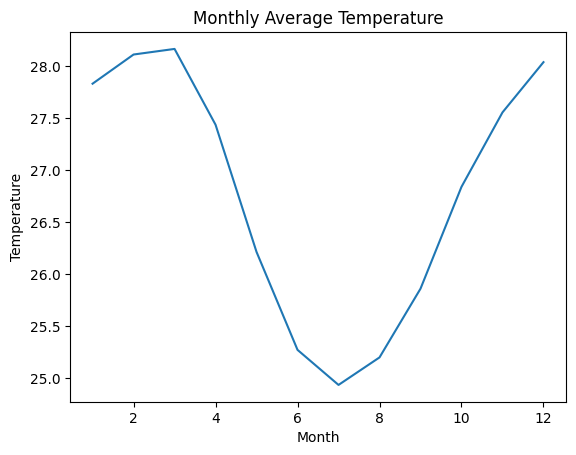

In [32]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

Monthly Precipitation

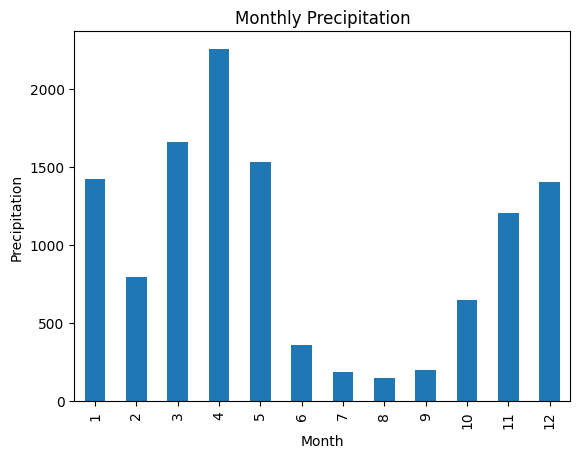

In [33]:
monthly_precip = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_precip.plot(kind="bar")
plt.title("Monthly Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

Correlation Analysis

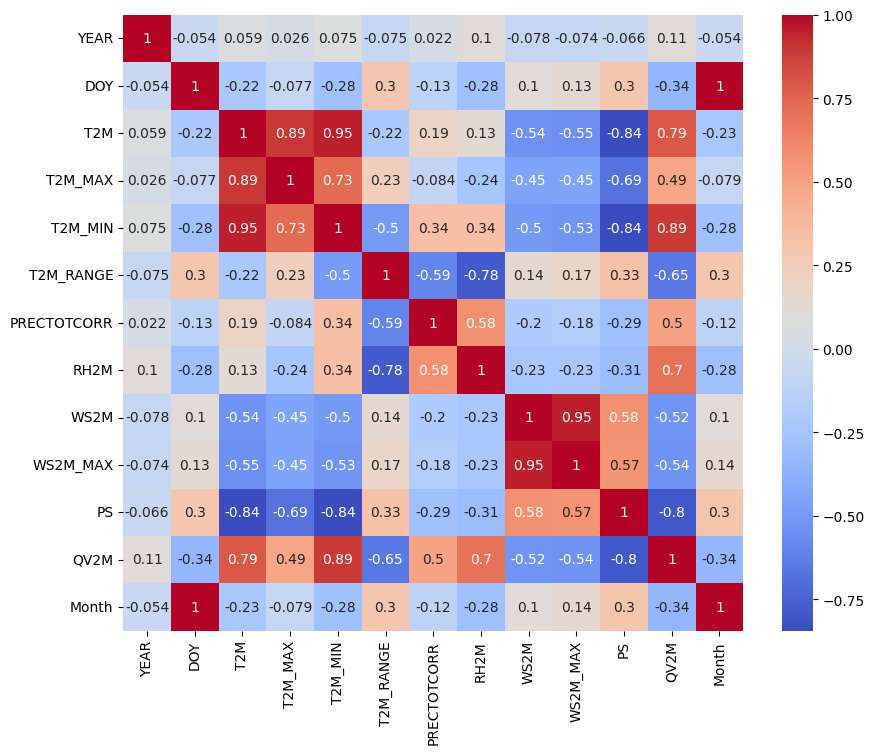

In [34]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Scatter plots

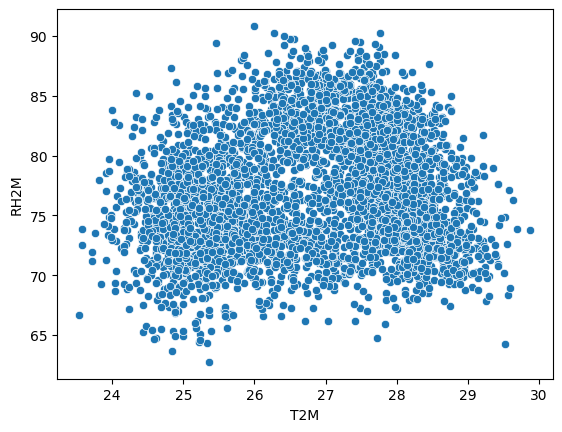

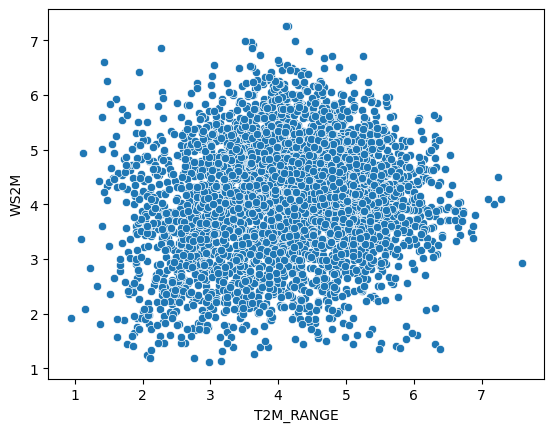

In [35]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

Histogram

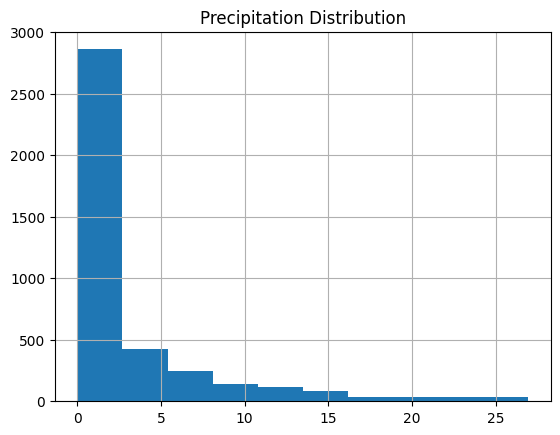

In [36]:
df["PRECTOTCORR"].hist()
plt.title("Precipitation Distribution")
plt.show()

Bubble Chart

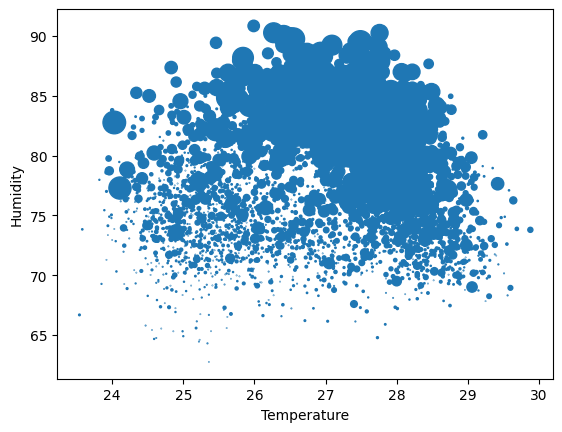

In [37]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()